In [2]:
pip install seaborn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Titanic_Train.csv")


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df['Survived'].head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

question 1

NameError: name 'ax' is not defined

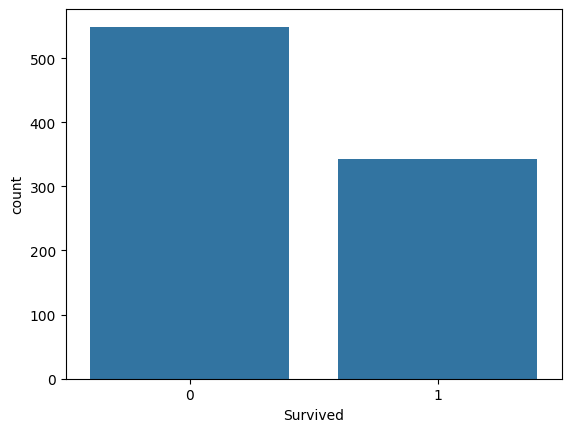

In [8]:
x = sns.countplot(x='Survived', data=df)

counts = df['Survived'].value_counts().sort_index()
total = counts.sum()


for i, count in enumerate(counts):
    percent = count / total * 100
    ax.text(i, count + 5, f'{percent:.1f}%', ha='center')


ax.set_xticklabels(['Did Not Survive', 'Survived'])
ax.set_ylabel('Number of Passengers')
ax.set_title('Titanic Survival Counts with Percentages')

plt.show()


Question 2

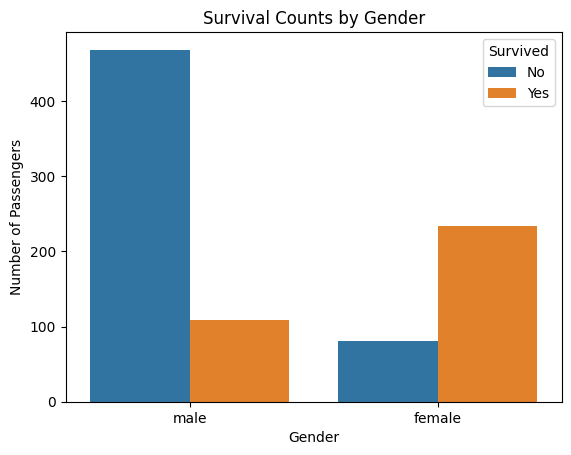

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Survival Counts by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No','Yes'])
plt.show()


Question 3

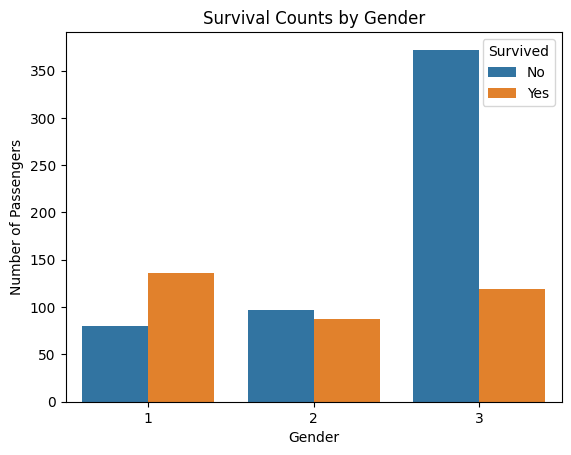

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title('Survival Counts by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No','Yes'])
plt.show()


Question 4

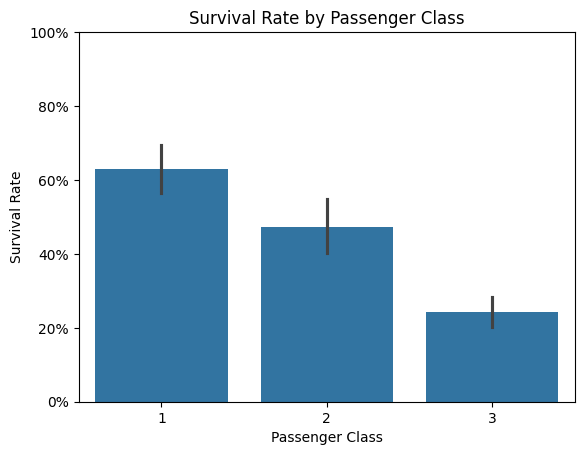

In [ ]:
survival_by_class = df.groupby('Pclass')['Survived'].mean()

sns.barplot(x='Pclass', y='Survived', data=df, order=[1, 2, 3])

plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.title('Survival Rate by Passenger Class')
plt.ylim(0, 1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0%', '20%', '40%', '60%', '80%', '100%'])
plt.show()


Question 4

In [ ]:
print(df['Age'].isnull().sum())
df_age = df.dropna(subset=['Age'])


177


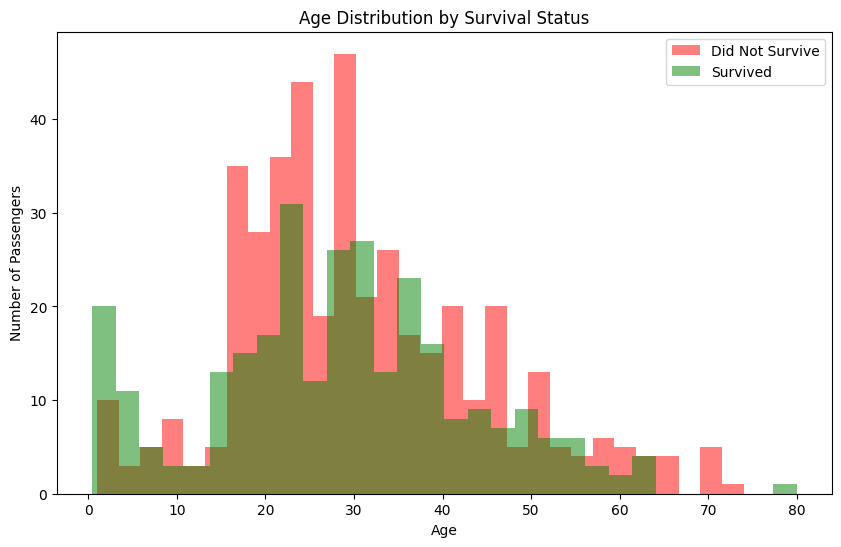

In [ ]:
plt.figure(figsize=(10,6))


plt.hist(df_age[df_age['Survived'] == 0]['Age'], bins=30, alpha=0.5, label='Did Not Survive', color='red')


plt.hist(df_age[df_age['Survived'] == 1]['Age'], bins=30, alpha=0.5, label='Survived', color='green')

plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution by Survival Status')
plt.legend()
plt.show()


Question 5

In [ ]:
# Drop missing ages to avoid errors
df_age = df.dropna(subset=['Age']).copy()

# Define age bins and labels
bins = [0, 12, 19, 59, 120]
labels = ['Children', 'Youth', 'Adults', 'Elderly']

# Create age group column
df_age['AgeGroup'] = pd.cut(df_age['Age'], bins=bins, labels=labels, right=True)

df_age.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adults
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adults
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adults
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adults
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adults


In [ ]:
survival_by_agegroup = df_age.groupby('AgeGroup')['Survived'].mean() * 100
print(survival_by_agegroup)


AgeGroup
Children    57.971014
Youth       41.052632
Adults      38.931298
Elderly     26.923077
Name: Survived, dtype: float64


/tmp/ipykernel_15924/1151483539.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_agegroup = df_age.groupby('AgeGroup')['Survived'].mean() * 100


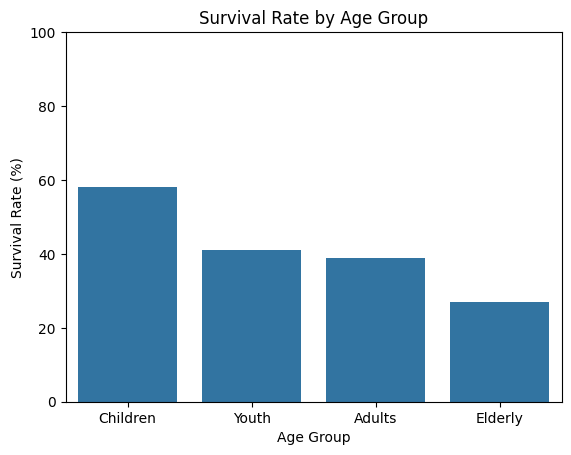

In [ ]:
sns.barplot(x=survival_by_agegroup.index, y=survival_by_agegroup.values)

plt.ylabel('Survival Rate (%)')
plt.xlabel('Age Group')
plt.title('Survival Rate by Age Group')
plt.ylim(0, 100)
plt.show()


Question 6

In [ ]:
df['family_size'] = df['SibSp'] + df['Parch'] + 1


In [ ]:
survival_by_family_size = df.groupby('family_size')['Survived'].mean() * 100
print(survival_by_family_size)


family_size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64


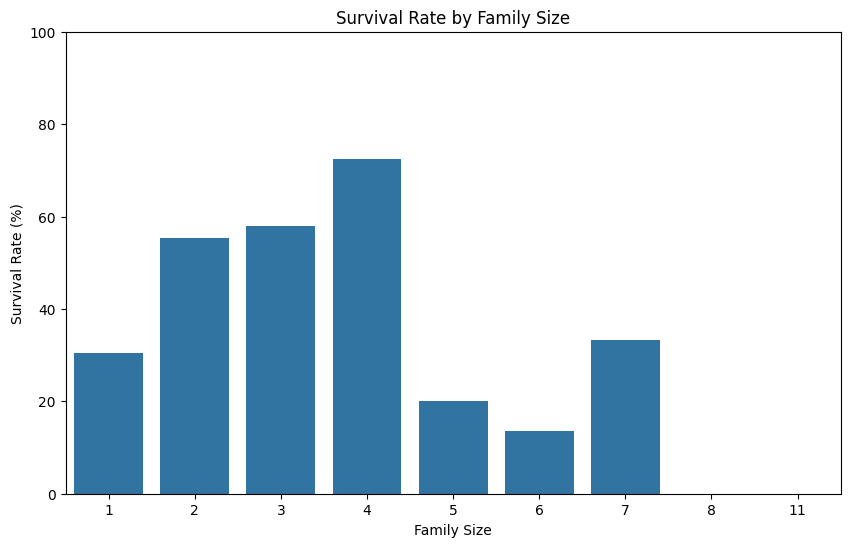

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=survival_by_family_size.index, y=survival_by_family_size.values)

plt.xlabel('Family Size')
plt.ylabel('Survival Rate (%)')
plt.title('Survival Rate by Family Size')
plt.ylim(0, 100)
plt.show()

Question 7

In [ ]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
survival_by_port = df.groupby('Embarked')['Survived'].mean() * 100
print(survival_by_port)

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64


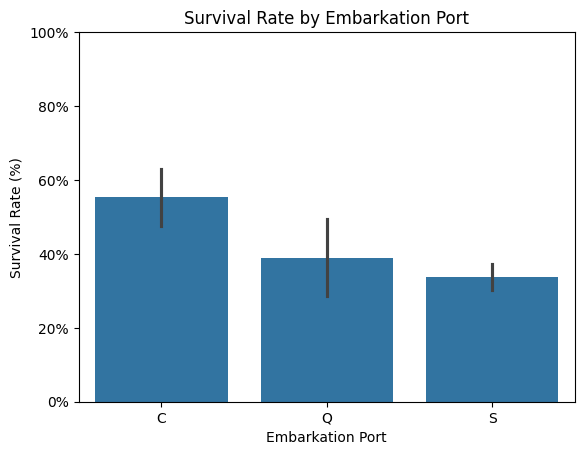

In [ ]:
df_embarked = df.dropna(subset=['Embarked'])

sns.barplot(x='Embarked', y='Survived', data=df_embarked, order=['C', 'Q', 'S'])

plt.xlabel('Embarkation Port')
plt.ylabel('Survival Rate (%)')
plt.title('Survival Rate by Embarkation Port')
plt.ylim(0, 1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0%', '20%', '40%', '60%', '80%', '100%'])
plt.show()

Question 8

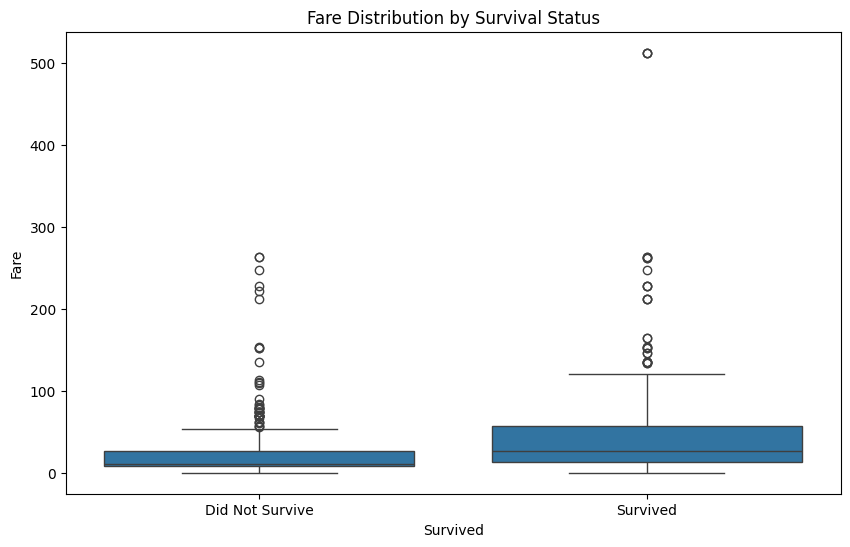

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Survived', y='Fare', data=df)

plt.xlabel('Survived')
plt.ylabel('Fare')
plt.title('Fare Distribution by Survival Status')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.show()

Question 9

In [9]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percent
})

print(missing_df)


             Missing Count  Missing Percentage
PassengerId              0            0.000000
Survived                 0            0.000000
Pclass                   0            0.000000
Name                     0            0.000000
Sex                      0            0.000000
Age                    177           19.865320
SibSp                    0            0.000000
Parch                    0            0.000000
Ticket                   0            0.000000
Fare                     0            0.000000
Cabin                  687           77.104377
Embarked                 2            0.224467
